In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression

In [2]:
#load data
df = pd.read_csv("D:\Projects\Project-credit-risk-dashboard\model\data\cs-training.csv")

In [ ]:
df

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [4]:
#dropping unnamed column
df = df.drop('Unnamed: 0', axis=1)

In [ ]:
#EDA
#checking missing values
df.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [6]:
df.dtypes

SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

In [7]:
#we wanted to see whether the class was imbalce or balance
df['SeriousDlqin2yrs'].value_counts(normalize=True)

SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

In [8]:
df.shape

(150000, 11)

In [9]:
#we wanted to check whether the missing values had any meaning or was just random so we used this two code below to check if 'True' value is greater
# than or not
df.groupby(df['MonthlyIncome'].isnull())['SeriousDlqin2yrs'].mean()

MonthlyIncome
False    0.069486
True     0.056137
Name: SeriousDlqin2yrs, dtype: float64

In [10]:
df.groupby(df['NumberOfDependents'].isnull())['SeriousDlqin2yrs'].mean()

NumberOfDependents
False    0.067410
True     0.045617
Name: SeriousDlqin2yrs, dtype: float64

In [11]:
#train-test split
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['SeriousDlqin2yrs']
)

In [12]:
#to counter the "SettingWithCopyWarning"
train_df = train_df.copy()
val_df = val_df.copy()

In [13]:
#Feature Engineering
train_df["MonthlyIncome_missing"] = train_df["MonthlyIncome"].isnull().astype(int) 
val_df["MonthlyIncome_missing"] = val_df["MonthlyIncome"].isnull().astype(int)

train_df["NumberOfDependents_missing"] = train_df["NumberOfDependents"].isnull().astype(int) 
val_df["NumberOfDependents_missing"] = val_df["NumberOfDependents"].isnull().astype(int)

In [14]:
#filling missing values with median
median_income = train_df['MonthlyIncome'].median()
train_df['MonthlyIncome'] = train_df['MonthlyIncome'].fillna(median_income)
val_df['MonthlyIncome'] = val_df['MonthlyIncome'].fillna(median_income)

median_dependents = train_df['NumberOfDependents'].median()
train_df['NumberOfDependents'] = train_df['NumberOfDependents'].fillna(median_dependents)
val_df['NumberOfDependents'] = val_df['NumberOfDependents'].fillna(median_dependents)

In [15]:
#defining X and y
X_train = train_df.drop('SeriousDlqin2yrs', axis=1)
X_val = val_df.drop('SeriousDlqin2yrs', axis=1)

y_train = train_df['SeriousDlqin2yrs']
y_val = val_df['SeriousDlqin2yrs']

In [16]:
X_train.isnull().sum()

RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
MonthlyIncome_missing                   0
NumberOfDependents_missing              0
dtype: int64

In [17]:
#Model Building
from xgboost import XGBClassifier

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

model = XGBClassifier(
    n_estimators = 150,
    max_depth = 4,
    learning_rate = 0.1,
    scale_pos_weight = scale_pos_weight,
    eval_metric = 'aucpr',
    random_state = 42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)

[0]	validation_0-aucpr:0.35195
[1]	validation_0-aucpr:0.36202
[2]	validation_0-aucpr:0.37038
[3]	validation_0-aucpr:0.37204
[4]	validation_0-aucpr:0.37600
[5]	validation_0-aucpr:0.37583
[6]	validation_0-aucpr:0.37764
[7]	validation_0-aucpr:0.37947
[8]	validation_0-aucpr:0.38224
[9]	validation_0-aucpr:0.38253
[10]	validation_0-aucpr:0.38306
[11]	validation_0-aucpr:0.38508
[12]	validation_0-aucpr:0.38531
[13]	validation_0-aucpr:0.38599
[14]	validation_0-aucpr:0.38679
[15]	validation_0-aucpr:0.38725
[16]	validation_0-aucpr:0.38928
[17]	validation_0-aucpr:0.39042
[18]	validation_0-aucpr:0.39014
[19]	validation_0-aucpr:0.39063
[20]	validation_0-aucpr:0.39072
[21]	validation_0-aucpr:0.39208
[22]	validation_0-aucpr:0.39307
[23]	validation_0-aucpr:0.39376
[24]	validation_0-aucpr:0.39724
[25]	validation_0-aucpr:0.39758
[26]	validation_0-aucpr:0.39886
[27]	validation_0-aucpr:0.40076
[28]	validation_0-aucpr:0.40126
[29]	validation_0-aucpr:0.40139
[30]	validation_0-aucpr:0.40075
[31]	validation_0-

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'aucpr'


In [20]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score
)

y_pred = model.predict(X_val)

y_pred_proba = model.predict_proba(X_val)
y_pred_proba = y_pred_proba[:, 1]

In [21]:
print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))
print(roc_auc_score(y_val, y_pred_proba))
print(average_precision_score(y_val, y_pred_proba))

[[22402  5593]
 [  444  1561]]
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27995
           1       0.22      0.78      0.34      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.79      0.61     30000
weighted avg       0.93      0.80      0.85     30000

0.869130923361359
0.40757913312051286


In [24]:
#SHAP 
import shap

In [25]:
explainer = shap.TreeExplainer(model)
X_small = X_val.iloc[:5]

In [26]:
shap_values = explainer(X_small)
print(shap_values.values.shape)

(5, 12)


In [27]:
shap_values.base_values

array([0.00148448, 0.00148448, 0.00148448, 0.00148448, 0.00148448],
      dtype=float32)

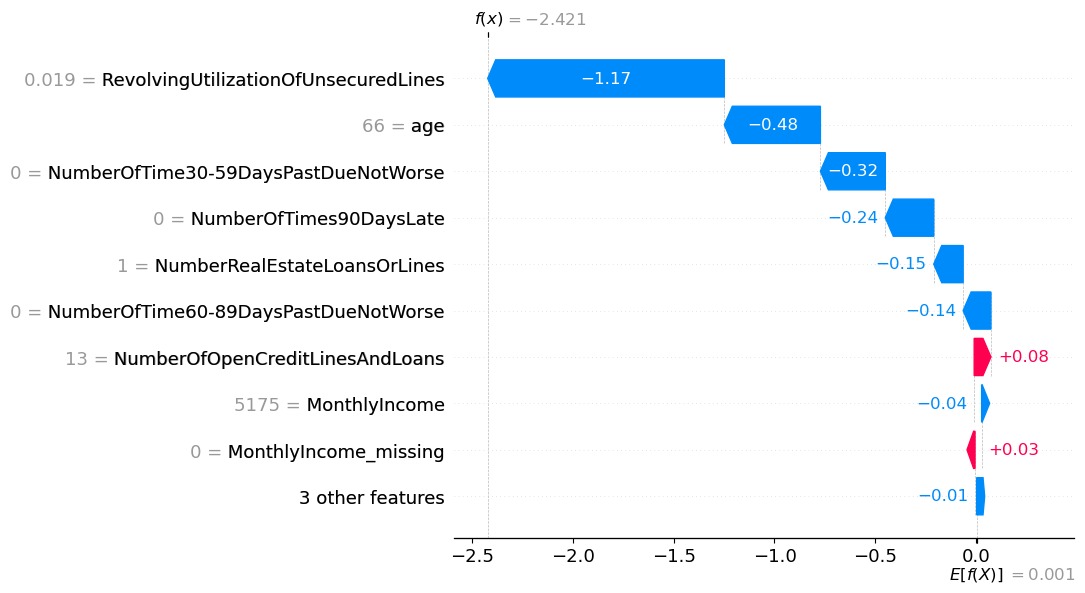

In [29]:
shap.plots.waterfall(shap_values[0])

In [30]:
X_val.iloc[0]

RevolvingUtilizationOfUnsecuredLines       0.019252
age                                       66.000000
NumberOfTime30-59DaysPastDueNotWorse       0.000000
DebtRatio                                  0.433926
MonthlyIncome                           5175.000000
NumberOfOpenCreditLinesAndLoans           13.000000
NumberOfTimes90DaysLate                    0.000000
NumberRealEstateLoansOrLines               1.000000
NumberOfTime60-89DaysPastDueNotWorse       0.000000
NumberOfDependents                         0.000000
MonthlyIncome_missing                      0.000000
NumberOfDependents_missing                 0.000000
Name: 10682, dtype: float64

In [31]:
shap_values[0]

.values =
array([-1.1721501e+00, -4.7594851e-01, -3.2145649e-01,  5.8565652e-03,
       -3.6926549e-02,  8.3024681e-02, -2.3993203e-01, -1.4571328e-01,
       -1.3759343e-01, -1.4867807e-02,  3.2754522e-02,  8.3210174e-04],
      dtype=float32)

.base_values =
np.float32(0.001484482)

.data =
array([1.92520810e-02, 6.60000000e+01, 0.00000000e+00, 4.33925811e-01,
       5.17500000e+03, 1.30000000e+01, 0.00000000e+00, 1.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

In [32]:
def get_top_shap_features(row, shap_explanation, top_n=5):
    feature_info = []

    for feature_name, feature_value, shap_value in zip(
        row.index,
        row.values,
        shap_explanation.values
    ):
        feature_info.append({
            "feature": feature_name,
            "value": feature_value,
            "shap": shap_value,
            "impact": "increases_risk" if shap_value > 0 else "decreases_risk"
        })

    # Sort by absolute SHAP value (largest impact first)
    feature_info = sorted(
        feature_info,
        key=lambda x: abs(x["shap"]),
        reverse=True
    )

    return feature_info[:top_n]

In [33]:
top_features = get_top_shap_features(
    X_val.iloc[0],
    shap_values[0]
)

top_features

[{'feature': 'RevolvingUtilizationOfUnsecuredLines',
  'value': np.float64(0.019252081),
  'shap': np.float32(-1.1721501),
  'impact': 'decreases_risk'},
 {'feature': 'age',
  'value': np.float64(66.0),
  'shap': np.float32(-0.4759485),
  'impact': 'decreases_risk'},
 {'feature': 'NumberOfTime30-59DaysPastDueNotWorse',
  'value': np.float64(0.0),
  'shap': np.float32(-0.3214565),
  'impact': 'decreases_risk'},
 {'feature': 'NumberOfTimes90DaysLate',
  'value': np.float64(0.0),
  'shap': np.float32(-0.23993203),
  'impact': 'decreases_risk'},
 {'feature': 'NumberRealEstateLoansOrLines',
  'value': np.float64(1.0),
  'shap': np.float32(-0.14571328),
  'impact': 'decreases_risk'}]

In [34]:
#verifying the raw_margin_sum is not equal to model probability
raw_margin_sum = shap_values[0].base_values + shap_values[0].values.sum()
print(raw_margin_sum)

# compare against:
print(model.predict_proba(X_val.iloc[[0]])[:, 1])

-2.4206362
[0.08161256]


In [35]:
prob = 1 / (1 + np.exp(-raw_margin_sum))
print(prob)

0.081612565


In [36]:
imputation_values = {"MonthlyIncome": median_income, "NumberOfDependents": median_dependents}

In [40]:
joblib.dump(model, r"D:\Projects\Project-credit-risk-dashboard\model\artifacts\model.pkl")
joblib.dump(imputation_values, r"D:\Projects\Project-credit-risk-dashboard\model\artifacts\imputation_values.pkl")

['D:\\Projects\\Project-credit-risk-dashboard\\model\\artifacts\\imputation_values.pkl']